## Interactive Plots

### embeddings visualization

In [ ]:
import cv2
import numpy as np

import fiftyone as fo
import fiftyone.brain as fob
import fiftyone.zoo as foz

In [ ]:
fo.list_datasets()

['coco-2017-test',
 'demo0424',
 'evaluate-detections-tutorial',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'mnist-test',
 'quickstart',
 'test_raw_imgs']

In [ ]:
fo.delete_dataset("mnist-test")

In [ ]:
dataset = foz.load_zoo_dataset("mnist", split="test")

# Construct a `num_samples x num_pixels` array of images
images = np.array([
    cv2.imread(f, cv2.IMREAD_UNCHANGED).ravel()
    for f in dataset.values("filepath")
])

Split 'test' already downloaded


Loading 'mnist' split 'test'
 100% |█████████████| 10000/10000 [1.9s elapsed, 0s remaining, 5.3K samples/s]         
Dataset 'mnist-test' created


In [ ]:
cv2.imread(dataset.first().filepath, cv2.IMREAD_UNCHANGED).shape

(28, 28)

In [ ]:
len(images[0])

784

In [ ]:
results = fob.compute_visualization(dataset, embeddings=images, seed=51)

Generating visualization...


/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP(n_jobs=1, random_state=51, verbose=True)
Thu Jun 19 15:41:40 2025 Construct fuzzy simplicial set
Thu Jun 19 15:41:40 2025 Finding Nearest Neighbors
Thu Jun 19 15:41:40 2025 Building RP forest with 10 trees
Thu Jun 19 15:41:42 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Thu Jun 19 15:41:46 2025 Finished Nearest Neighbor Search
Thu Jun 19 15:41:47 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Jun 19 15:41:57 2025 Finished embedding



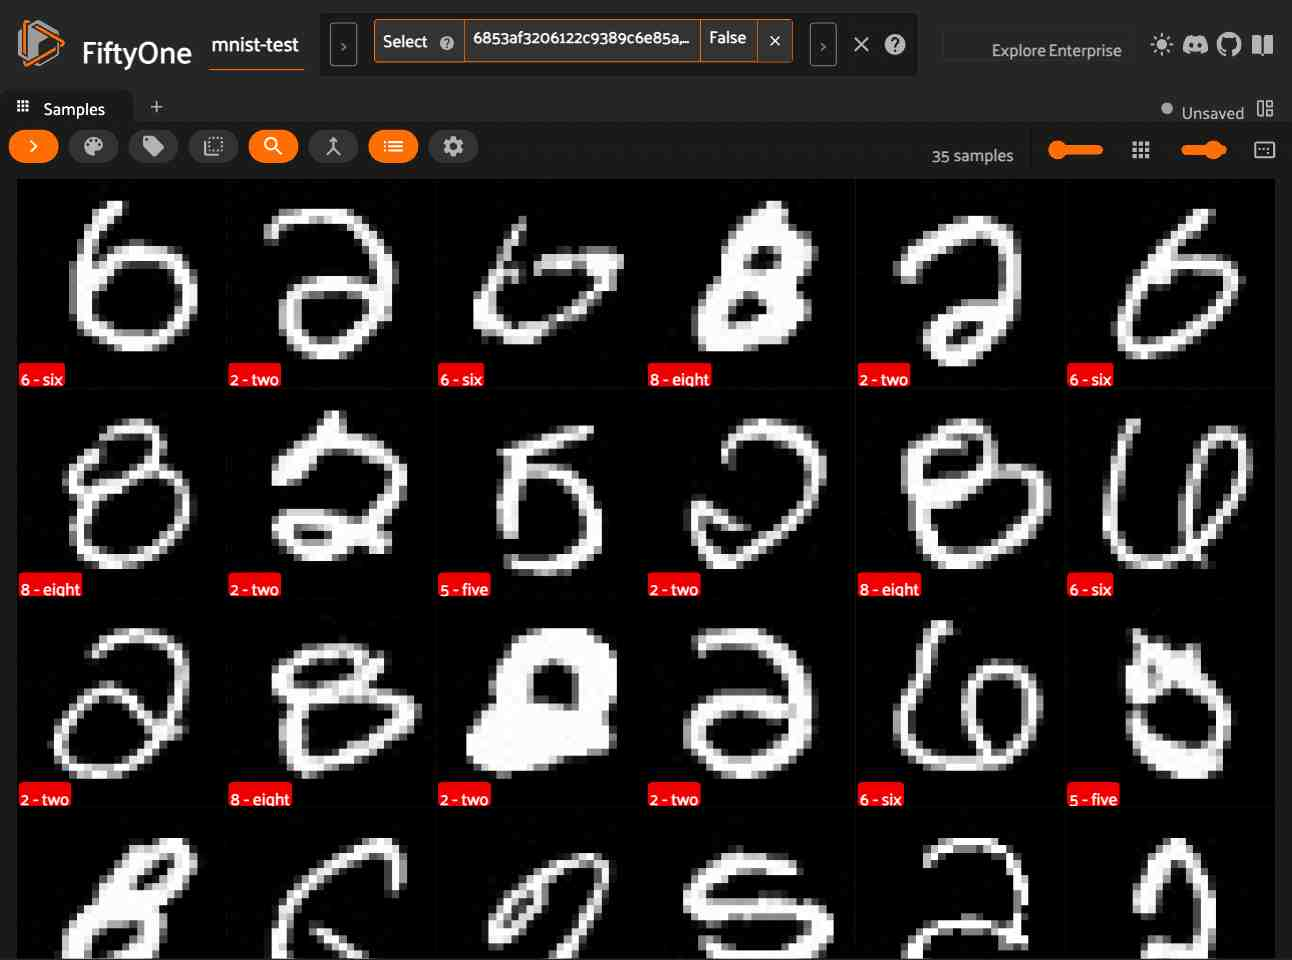

In [ ]:
session = fo.launch_app(dataset)

In [ ]:
plot = results.visualize(labels="ground_truth.label")
plot.show(height=720)

session.plots.attach(plot)

FigureWidget({
    'data': [{'customdata': array(['6853af3206122c9389c6e4df', '6853af3206122c9389c6e526',
                                   '6853af3206122c9389c6e529', ..., '6853af3406122c9389c732cf',
                                   '6853af3406122c9389c732e2', '6853af3406122c9389c732ec'], dtype=object),
              'hovertemplate': ('<b>label: %{text}</b><br>x, y ' ... ': %{customdata}<extra></extra>'),
              'line': {'color': '#3366CC'},
              'mode': 'markers',
              'name': '0 - zero',
              'showlegend': True,
              'text': array(['0 - zero', '0 - zero', '0 - zero', ..., '0 - zero', '0 - zero',
                             '0 - zero'], dtype='<U8'),
              'type': 'scattergl',
              'uid': 'ed7987a3-4fd1-4513-a0af-2773e6d02617',
              'x': array([ 0.04024412, -0.48399627,  0.14459968, ..., -1.1108587 , -0.8116359 ,
                          -1.6506398 ], dtype=float32),
              'y': array([5.3942065, 6.24086

### geolocation

 100% |████|  223.5Mb/223.5Mb [1.7s elapsed, 0s remaining, 120.2Mb/s]         
Extracting dataset...
Parsing dataset metadata
Found 500 samples
Dataset info written to '/Users/bhc/fiftyone/quickstart-geo/info.json'
Loading 'quickstart-geo'
 100% |█████████████████| 500/500 [3.8s elapsed, 0s remaining, 130.3 samples/s]      
Dataset 'quickstart-geo' created
Computing embeddings...
 100% |█████████████████| 500/500 [5.7s elapsed, 0s remaining, 89.0 samples/s]      
Computing uniqueness...
Generating index for 500 embeddings...
Index complete
Uniqueness computation complete



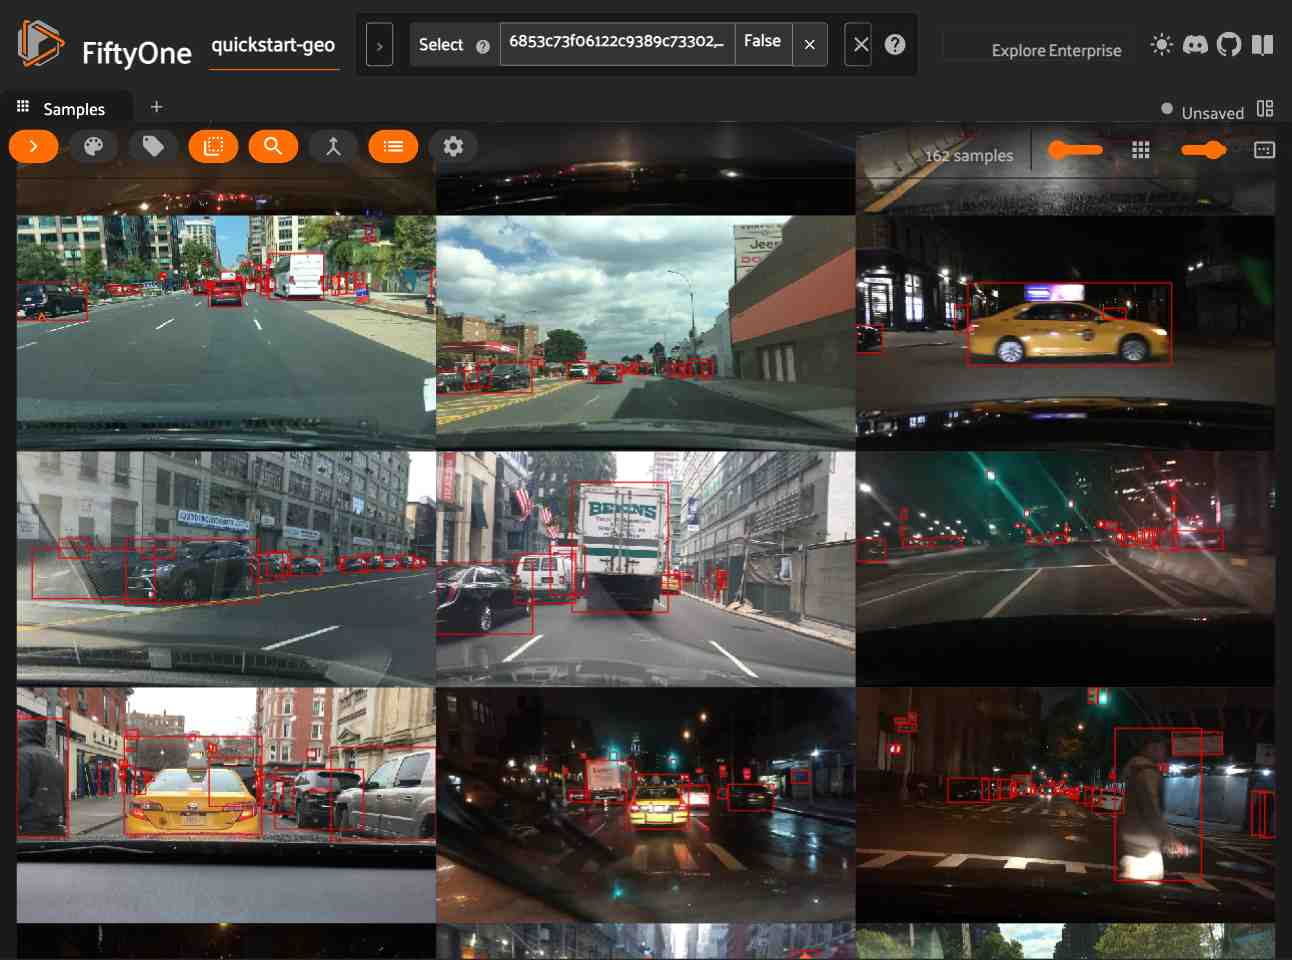

In [ ]:
from fiftyone import ViewField as F

dataset = foz.load_zoo_dataset("quickstart-geo")
fob.compute_uniqueness(dataset)

session = fo.launch_app(dataset)

In [ ]:
num_objects = F("ground_truth.detections").length()

plot = fo.location_scatterplot(
    samples=dataset,
    labels="uniqueness",    # color points by their `uniqueness` values
    sizes=num_objects,      # scale point sizes by number of objects
    sizes_title="objects",
)
plot.show(height=720)

session.plots.attach(plot)

FigureWidget({
    'data': [{'customdata': array(['6853c73f06122c9389c73301', '6853c73f06122c9389c73302',
                                   '6853c73f06122c9389c73303', ..., '6853c74306122c9389c734f2',
                                   '6853c74306122c9389c734f3', '6853c74306122c9389c734f4'], dtype=object),
              'hovertemplate': ('<b>uniqueness: %{marker.color}' ... ': %{customdata}<extra></extra>'),
              'lat': array([40.76392586, 40.723452  , 40.74994145, ..., 40.64721997, 40.5786707 ,
                            40.75949388]),
              'lon': array([-73.77615469, -74.00767703, -73.972425  , ..., -73.96070735,
                            -73.9741896 , -73.97648873]),
              'marker': {'color': array([0.07956989, 0.07819581, 0.52401968, ..., 0.54342706, 0.428165  ,
                                         0.3082185 ]),
                         'colorbar': {'len': 1, 'lenmode': 'fraction', 'title': {'text': 'uniqueness'}},
                         'colorsc

### regressions

Dataset already downloaded
Loading existing dataset 'quickstart'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use



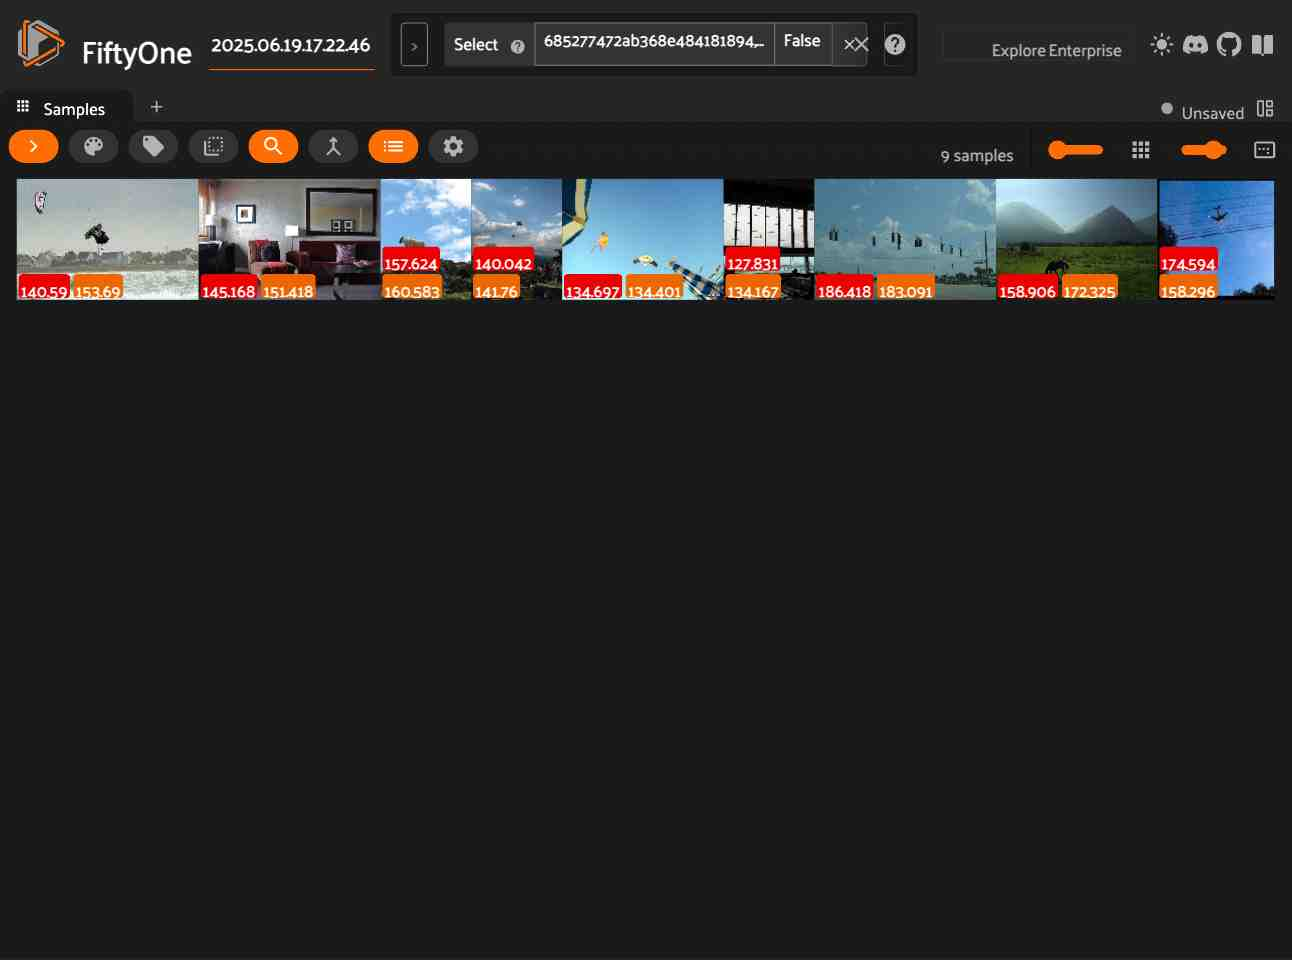

In [ ]:
import random
import numpy as np

dataset = foz.load_zoo_dataset("quickstart").select_fields().clone()

for idx, sample in enumerate(dataset, 1):
    ytrue = random.random() * idx
    ypred = ytrue + np.random.randn() * np.sqrt(ytrue)
    confidence = random.random()
    sample["ground_truth"] = fo.Regression(value=ytrue)
    sample["predictions"] = fo.Regression(value=ypred, confidence=confidence)
    sample["weather"] = random.choice(["sunny", "cloudy", "rainy"])
    sample.save()

results = dataset.evaluate_regressions(
    "predictions",
    gt_field="ground_truth",
    eval_key="eval",
)

session = fo.launch_app(dataset)

In [ ]:
plot = results.plot_results(labels="weather", sizes="predictions.confidence")
plot.show()

session.plots.attach(plot)

FigureWidget({
    'data': [{'line': {'color': 'black'},
              'mode': 'lines',
              'name': 'r^2: 0.971',
              'type': 'scatter',
              'uid': 'ca9e42dc-2caa-49cd-85ff-5de6b8f30af4',
              'x': array([  0.3952736 , 186.41804473]),
              'y': array([  0.34043508, 185.48461088])},
             {'customdata': array(['685277442ab368e48418180a', '685277442ab368e48418180b',
                                   '685277442ab368e48418180d', '685277462ab368e484181811',
                                   '685277462ab368e484181814', '685277462ab368e484181815',
                                   '685277462ab368e484181816', '685277462ab368e484181818',
                                   '685277462ab368e48418181c', '685277462ab368e484181828',
                                   '685277462ab368e484181829', '685277462ab368e484181833',
                                   '685277462ab368e484181834', '685277462ab368e484181835',
                                

### line plots (video frames)

In [ ]:
fo.list_datasets()

['2025.06.19.17.22.46',
 'coco-2017-test',
 'demo0424',
 'evaluate-detections-tutorial',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'mnist-test',
 'quickstart',
 'quickstart-geo',
 'test_raw_imgs']

Dataset already downloaded
Loading 'quickstart-video'
 100% |███████████████████| 10/10 [3.2s elapsed, 0s remaining, 3.2 samples/s]      
Dataset 'quickstart-video' created
Computing metadata...
 100% |███████████████████| 10/10 [2.7s elapsed, 0s remaining, 3.7 samples/s] 
 100% |███████████████| 1279/1279 [21.8ms elapsed, 0s remaining, 58.7K samples/s]   
Setting 1279 frame filepaths on the input collection that exist on disk but are not recorded on the dataset
Sampling video frames...
 100% |███████████████████| 10/10 [10.6s elapsed, 0s remaining, 0.9 samples/s]   



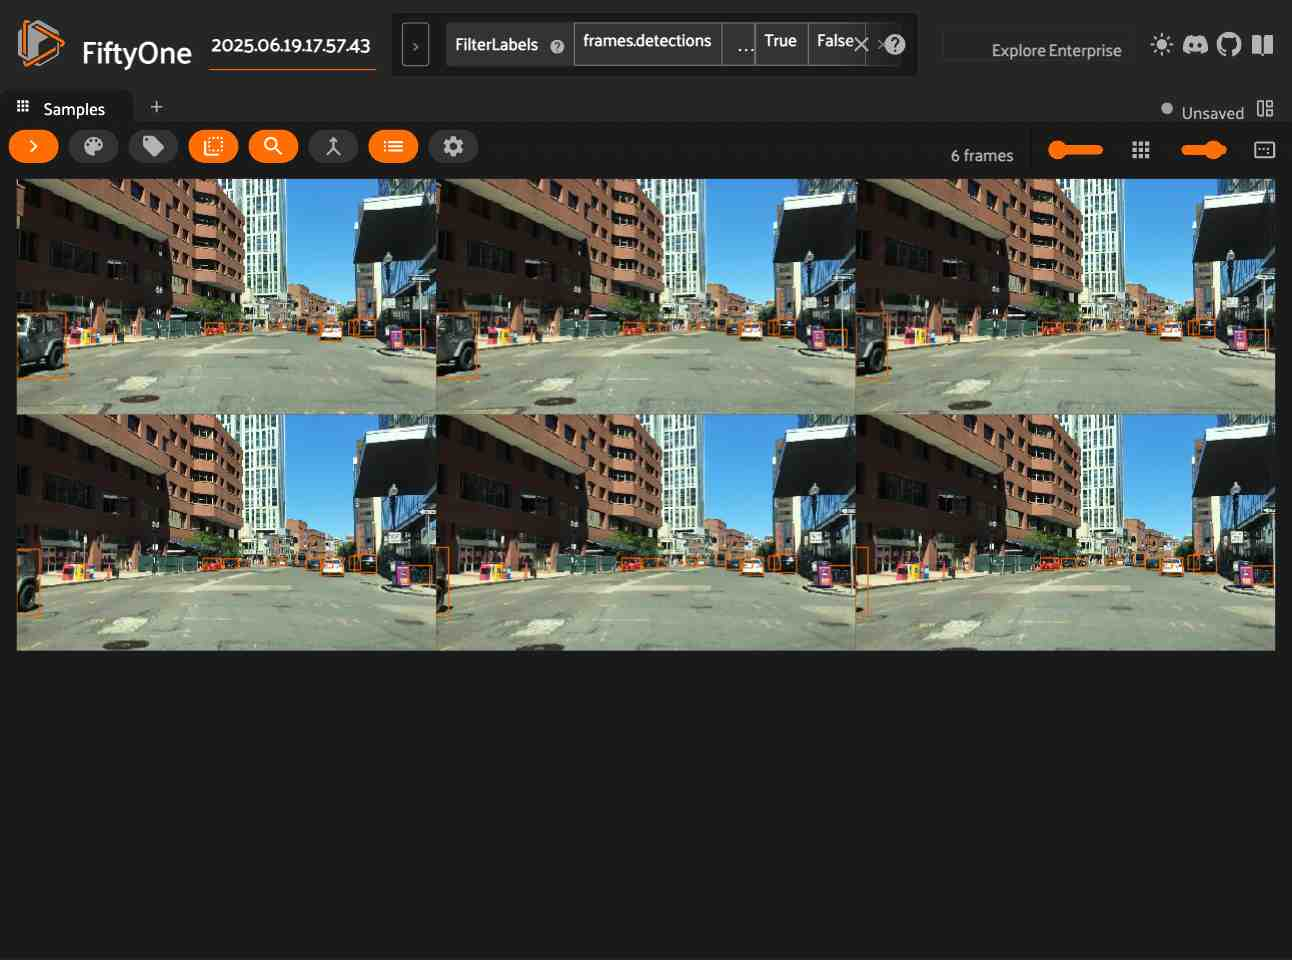

In [ ]:
dataset = foz.load_zoo_dataset("quickstart-video").clone()
dataset.to_frames(sample_frames=True)

session = fo.launch_app(dataset)

In [ ]:
view = dataset.filter_labels("frames.detections", F("label") == "vehicle")

plot = fo.lines(
    x="frames.frame_number",
    y=F("frames.detections.detections").length(),
    labels="id",
    samples=view,
    xaxis_title="frame number",
    yaxis_title="num vehicles",
)
plot.show()
plot.selection_mode = "frames"

session.plots.attach(plot)

FigureWidget({
    'data': [{'customdata': array(['6853d104fbf4baefa1d6b875', '6853d104fbf4baefa1d6b876',
                                   '6853d104fbf4baefa1d6b877', '6853d104fbf4baefa1d6b878',
                                   '6853d104fbf4baefa1d6b879', '6853d104fbf4baefa1d6b87a',
                                   '6853d104fbf4baefa1d6b87b', '6853d104fbf4baefa1d6b87c',
                                   '6853d104fbf4baefa1d6b87d', '6853d104fbf4baefa1d6b87e',
                                   '6853d104fbf4baefa1d6b87f', '6853d104fbf4baefa1d6b880',
                                   '6853d104fbf4baefa1d6b881', '6853d104fbf4baefa1d6b882',
                                   '6853d104fbf4baefa1d6b883', '6853d104fbf4baefa1d6b884',
                                   '6853d104fbf4baefa1d6b885', '6853d104fbf4baefa1d6b886',
                                   '6853d104fbf4baefa1d6b887', '6853d104fbf4baefa1d6b888',
                                   '6853d104fbf4baefa1d6b889', '6853d104fbf

 100% |███████████████| 1279/1279 [23.8ms elapsed, 0s remaining, 53.8K samples/s]      


### confusion matrices

Dataset already downloaded
Loading existing dataset 'quickstart'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use
Evaluating detections...
 100% |█████████████████| 200/200 [1.5s elapsed, 0s remaining, 124.4 samples/s]         



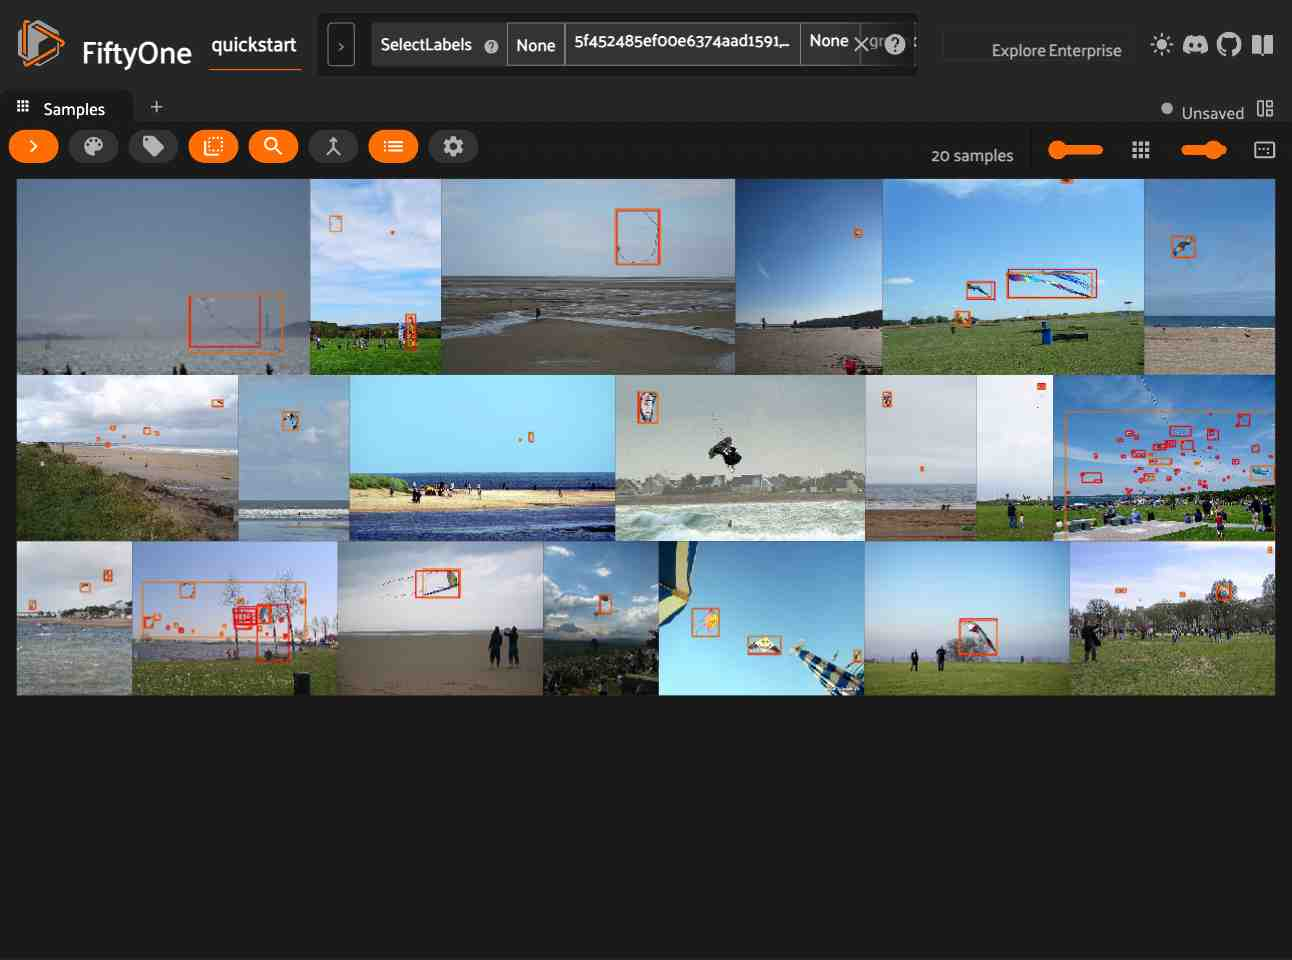

In [ ]:
dataset = foz.load_zoo_dataset("quickstart")
results = dataset.evaluate_detections("predictions", gt_field="ground_truth")

counts = dataset.count_values("ground_truth.detections.label")
classes = sorted(counts, key=counts.get, reverse=True)[:10]

session = fo.launch_app(dataset)

In [ ]:
plot = results.plot_confusion_matrix(classes=classes)
plot.show(height=600)

session.plots.attach(plot)

FigureWidget({
    'data': [{'mode': 'markers',
              'opacity': 0.1,
              'type': 'scatter',
              'uid': 'dc2585a2-f358-420c-b3dd-a700ebe10760',
              'x': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  1,  2,  3,  4,  5,  6,
                           7,  8,  9, 10,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  1,  2,
                           3,  4,  5,  6,  7,  8,  9, 10,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
                          10,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  1,  2,  3,  4,  5,
                           6,  7,  8,  9, 10,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  1,
                           2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  1,  2,  3,  4,  5,  6,  7,  8,
                           9, 10,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
              'y': array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
                           1,  1,  1,  1,  2,  2,  2,  2,  2, 

### view plots

Dataset already downloaded
Loading existing dataset 'quickstart'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use
Computing metadata...
 100% |█████████████████| 180/180 [29.2ms elapsed, 0s remaining, 6.2K samples/s] 



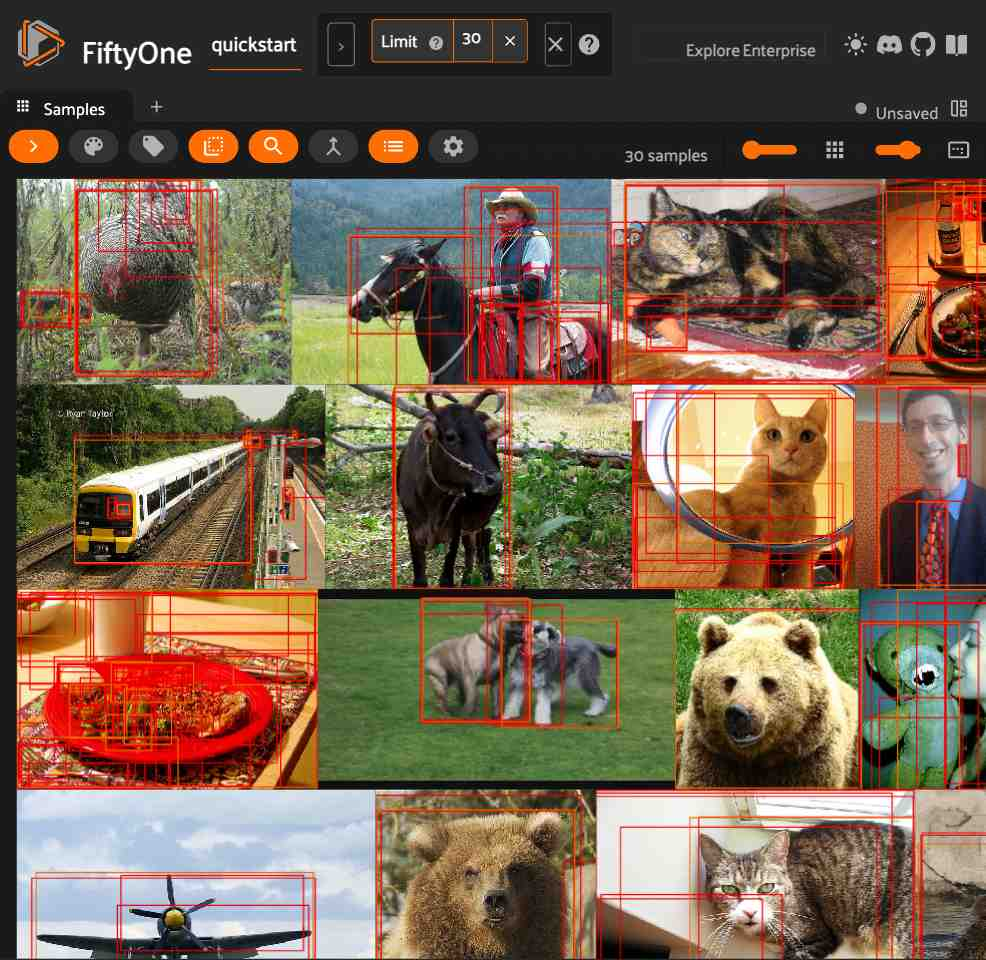

In [ ]:
dataset = foz.load_zoo_dataset("quickstart")
dataset.compute_metadata()

plot1 = fo.NumericalHistogram(F("metadata.size_bytes") / 1024, bins=50, xlabel="image size (KB)")
plot2 = fo.NumericalHistogram("predictions.detections.confidence", bins=50, range=[0, 1])
plot3 = fo.CategoricalHistogram("ground_truth.detections.label", order="frequency")
plot4 = fo.CategoricalHistogram("predictions.detections.label", order="frequency")

session = fo.launch_app(dataset)

In [ ]:
plot = fo.ViewGrid([plot1, plot2, plot3, plot4], init_view=dataset)
plot.show(height=720)

session.plots.attach(plot)

FigureWidget({
    'data': [{'customdata': array([[ 24.34277344,  30.71560549],
                                   [ 30.71560549,  37.08843754],
                                   [ 37.08843754,  43.46126959],
                                   [ 43.46126959,  49.83410164],
                                   [ 49.83410164,  56.20693369],
                                   [ 56.20693369,  62.57976574],
                                   [ 62.57976574,  68.9525978 ],
                                   [ 68.9525978 ,  75.32542985],
                                   [ 75.32542985,  81.6982619 ],
                                   [ 81.6982619 ,  88.07109395],
                                   [ 88.07109395,  94.443926  ],
                                   [ 94.443926  , 100.81675805],
                                   [100.81675805, 107.1895901 ],
                                   [107.1895901 , 113.56242215],
                                   [113.56242215, 119.93525421],
          

## Data Augmentation

In [5]:
# !fiftyone plugins download https://github.com/jacobmarks/fiftyone-albumentations-plugin
# !pip install albumentations==1.4.0

In [1]:
import fiftyone as fo
import fiftyone.zoo as foz

dataset = foz.load_zoo_dataset("kitti", split="train", max_samples=10)

Split 'train' already downloaded
Loading existing dataset 'kitti-train-10'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [2]:
from transformers import AutoModelForDepthEstimation
depth_model = AutoModelForDepthEstimation.from_pretrained(
    "Intel/dpt-large"
)
dataset.apply_model(depth_model, "depth")

Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.
/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 100% |███████████████████| 10/10 [11.6s elapsed, 0s remaining, 1.2 samples/s]   


In [3]:
from ultralytics import YOLO
pose_model = YOLO('yolov8x-pose.pt')
dataset.apply_model(pose_model, "keypoints")

/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 100% |███████████████████| 10/10 [3.5s elapsed, 0s remaining, 2.8 samples/s]      



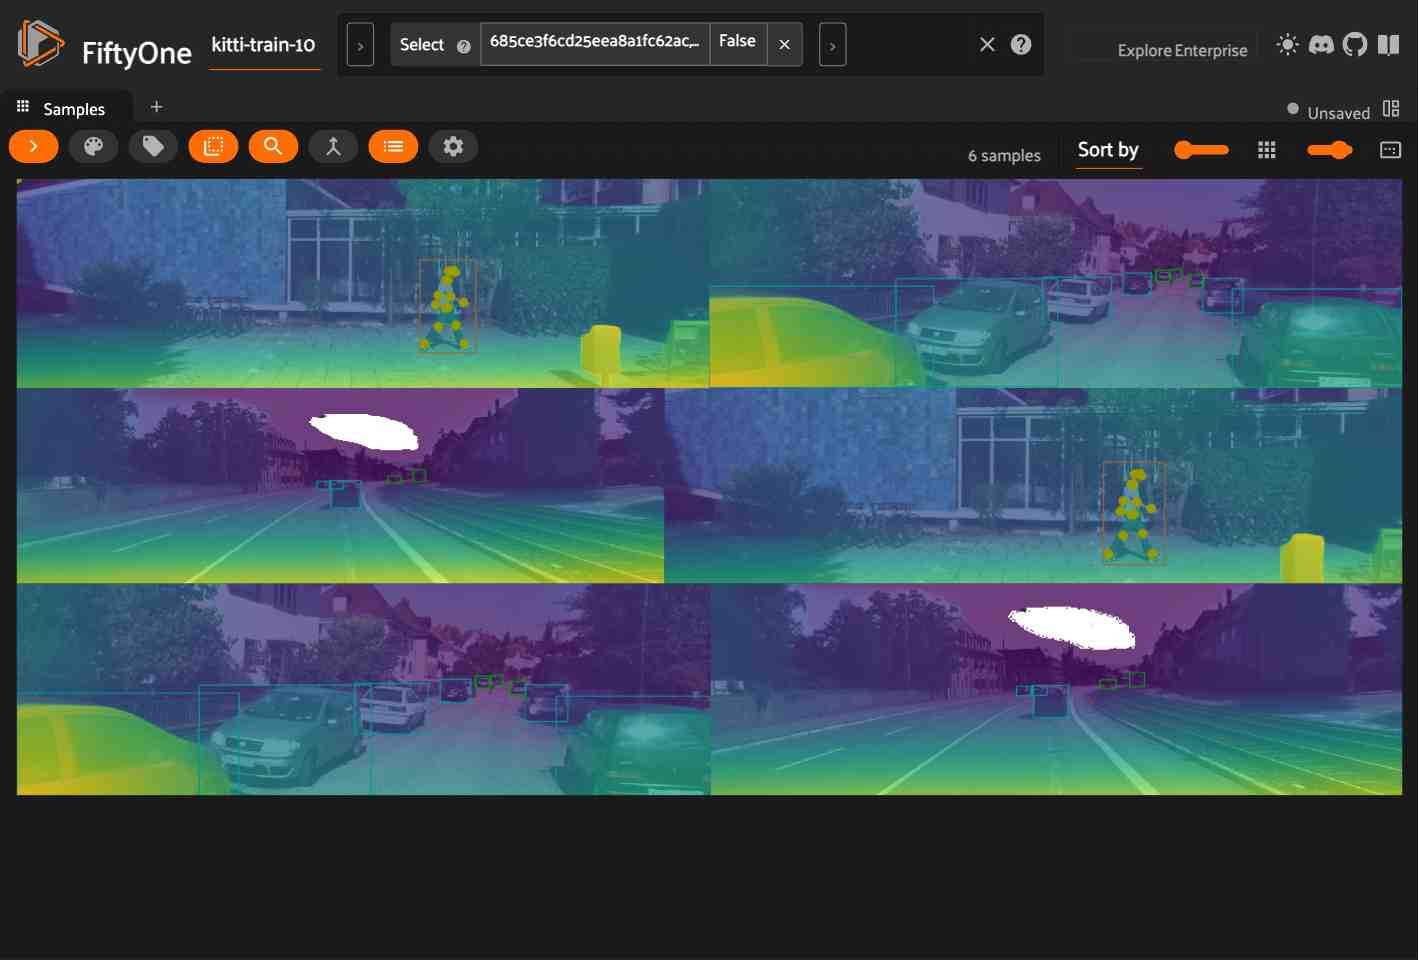


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 s

In [4]:
session = fo.launch_app(dataset, port=5151)

## Clustering Images

In [6]:
!fiftyone plugins download https://github.com/jacobmarks/clustering-plugin

  162.8Kb [4.7ms elapsed, ? remaining, 34.0Mb/s] 
Copying plugin '@jacobmarks/clustering' to '/Users/bhc/fiftyone/__plugins__/@jacobmarks/clustering'


In [7]:
import fiftyone as fo
import fiftyone.brain as fob
import fiftyone.zoo as foz
from fiftyone import ViewField as F

dataset = foz.load_zoo_dataset("coco-2017", split="validation")

## rm labels
dataset.select_fields().keep_fields()
dataset.name = "clustering-demo"

Found annotations at '/Users/bhc/fiftyone/coco-2017/raw/instances_val2017.json'
Images already downloaded
Existing download of split 'validation' is sufficient
Loading existing dataset 'coco-2017-validation'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [9]:
res = fob.compute_visualization(
    dataset,
    model="clip-vit-base32-torch",
    embeddings="clip_embeddings",
    method="umap",
    brain_key="clip_vis",
    batch_size=10
)
dataset.set_values("clip_umap", res.current_points)

Computing embeddings...


/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 100% |███████████████| 5000/5000 [1.2m elapsed, 0s remaining, 72.1 samples/s]      
Generating visualization...
UMAP( verbose=True)
Fri Jun 27 15:51:59 2025 Construct fuzzy simplicial set
Fri Jun 27 15:51:59 2025 Finding Nearest Neighbors
Fri Jun 27 15:51:59 2025 Building RP forest with 9 trees
Fri Jun 27 15:52:01 2025 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	 4  /  12
	 5  /  12
	Stopping threshold met -- exiting after 5 iterations
Fri Jun 27 15:52:05 2025 Finished Nearest Neighbor Search
Fri Jun 27 15:52:06 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Jun 27 15:52:08 2025 Finished embedding


In [ ]:
session = fo.launch_app(dataset)


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds



: 